In [42]:
import pandas as pd
import numpy as np

# World Happiness Report 2023 — representative data
# Source: https://www.kaggle.com/datasets/ajaypalsinghlo/world-happiness-report-2023

df = pd.read_csv('../data/world_happiness_2023.csv')
df.columns = ['Country','Region','Happiness_Score','GDP','Social_Support',
              'Life_Expectancy','Freedom','Generosity','Corruption']


print(f"Dataset: {len(df)} countries, {len(df.columns)} columns")
print(df.head())


Dataset: 63 countries, 9 columns
       Country                        Region  Happiness_Score     GDP  \
0      Finland                Western Europe            7.804  10.775   
1      Denmark                Western Europe            7.586  10.933   
2      Iceland                Western Europe            7.525  10.878   
3       Israel  Middle East and North Africa            7.473  10.527   
4  Netherlands                Western Europe            7.464  11.015   

   Social_Support  Life_Expectancy  Freedom  Generosity  Corruption  
0           0.954             71.9    0.949       0.142       0.179  
1           0.954             72.7    0.931       0.168       0.234  
2           0.983             72.5    0.961       0.260       0.150  
3           0.916             72.4    0.903       0.149       0.826  
4           0.939             72.4    0.879       0.240       0.296  


In [43]:
import plotly.express as px
import plotly.graph_objects as go

# Explore the dataset before you start
print("Regions in dataset:")
print(df['Region'].value_counts())
print("\nScore range:", df['Happiness_Score'].min(), "–", df['Happiness_Score'].max())
print("\nBottom 10 countries:")
print(df.nsmallest(10, 'Happiness_Score')[['Country','Region','Happiness_Score']])


Regions in dataset:
Region
Western Europe                  15
Latin America and Caribbean     13
Central and Eastern Europe       7
Sub-Saharan Africa               7
Middle East and North Africa     6
North America and ANZ            4
Southeast Asia                   4
South Asia                       4
East Asia                        3
Name: count, dtype: int64

Score range: 1.859 – 7.804

Bottom 10 countries:
        Country                        Region  Happiness_Score
60  Afghanistan                    South Asia            1.859
61      Lebanon  Middle East and North Africa            2.392
62     Zimbabwe            Sub-Saharan Africa            2.995
52     Ethiopia            Sub-Saharan Africa            3.564
53     Tanzania            Sub-Saharan Africa            3.698
48   Bangladesh                    South Asia            3.892
47        India                    South Asia            4.036
50        Kenya            Sub-Saharan Africa            4.112
54       Uganda

## Task 1 — Regional Comparison Bar Chart

What to build: A horizontal bar chart showing the average happiness score by region, sorted from highest to lowest.

Insight:Europe stands out as the happiest region due to higher living standards and strong social support systems.

In [44]:
# Task 1: Regional comparison bar chart

region_avg = (
    df.groupby('Region')['Happiness_Score']
    .mean()
    .reset_index()
    .sort_values('Happiness_Score')
)

fig = px.bar(
    region_avg,
    x='Happiness_Score',
    y='Region',
    orientation='h',
    title='Europe Stands Out as the Happiest Region',
    color='Happiness_Score',
    color_continuous_scale='Blues'
)

fig.show()
fig.write_image("task1_chart.png")


## Task 2 — Top vs Bottom Countries

This chart highlights the significant gap between the happiest and least happy countries, showing global inequality in happiness levels.

In [45]:
# Task 2: Top 8 vs. Bottom 8 contrast

top8 = df.nlargest(8, 'Happiness_Score').copy()
top8['Group'] = 'Top 8'

bottom8 = df.nsmallest(8, 'Happiness_Score').copy()
bottom8['Group'] = 'Bottom 8'

combined = pd.concat([bottom8, top8]).sort_values('Happiness_Score')

global_avg = df['Happiness_Score'].mean()

fig = px.bar(
    combined,
    x='Happiness_Score',
    y='Country',
    orientation='h',
    color='Group',
    title='My Insight: Gap Between Happiest and Least Happy Countries',
    color_discrete_map={'Top 8': 'green', 'Bottom 8': 'red'}
)

fig.add_vline(
    x=global_avg,
    line_dash="dash",
    line_color="blue",
    annotation_text="Average",
    annotation_position="top"
)

fig.show()
fig.write_image("task2_chart.png")



Task 3 — Grouped Bar Chart Comparison

What to build: A grouped bar chart comparing "GDP per capita" and "freedom" to make life choices across selected regions: Western Europe, Latin America, East Asia, Sub-Saharan Africa, and South Asia.

Insight:Western Europe stands out with higher GDP and freedom, while South Asia and Sub-Saharan Africa show comparatively lower values, highlighting regional inequality in economic development and personal freedom.

  Country name            Regional indicator  Ladder score  \
0      Finland                Western Europe         7.804   
1      Denmark                Western Europe         7.586   
2      Iceland                Western Europe         7.525   
3       Israel  Middle East and North Africa         7.473   
4  Netherlands                Western Europe         7.464   

   Logged GDP per capita  Social support  Healthy life expectancy  \
0                 10.775           0.954                     71.9   
1                 10.933           0.954                     72.7   
2                 10.878           0.983                     72.5   
3                 10.527           0.916                     72.4   
4                 11.015           0.939                     72.4   

   Freedom to make life choices  Generosity  Perceptions of corruption  
0                         0.949       0.142                      0.179  
1                         0.931       0.168                      0

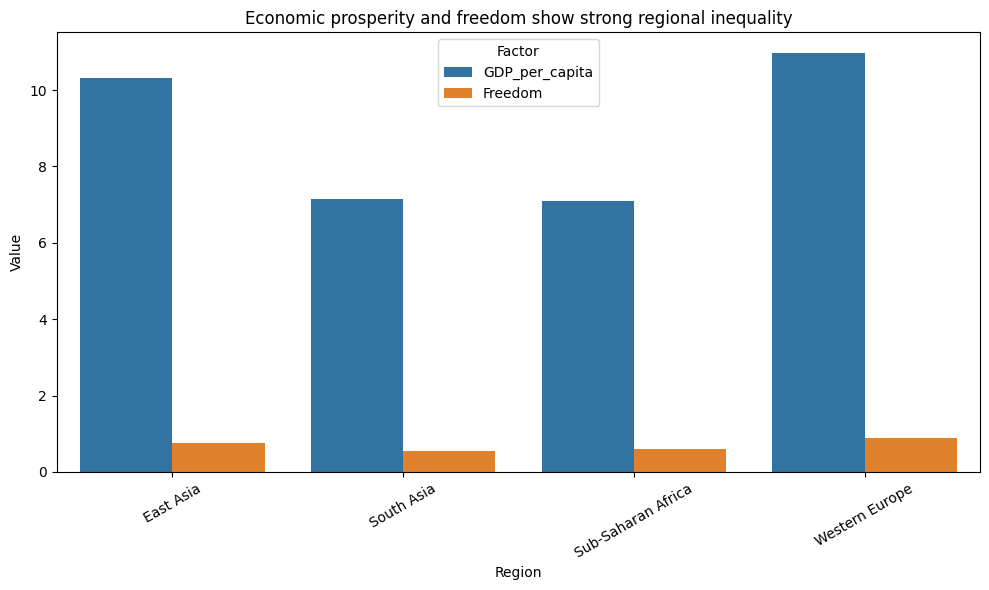

In [46]:
import pandas as pd

df = pd.read_csv(r"C:\Users\Lenovo\Desktop\data-viz-class-material\data\world_happiness_2023.csv")

print(df.head())

# Rename columns if needed
df = df.rename(columns={
    "Regional indicator": "Region",
    "Logged GDP per capita": "GDP_per_capita",
    "Freedom to make life choices": "Freedom"
})

# Regions required
regions = ['Western Europe', 'Latin America', 'East Asia', 
           'Sub-Saharan Africa', 'South Asia']

# Filter dataset
df_filtered = df[df["Region"].isin(regions)]

# Group by region and calculate mean values
grouped = df_filtered.groupby("Region")[["GDP_per_capita", "Freedom"]].mean().reset_index()

# Convert to long format for seaborn
df_melted = grouped.melt(id_vars="Region", 
                         value_vars=["GDP_per_capita", "Freedom"],
                         var_name="Factor", 
                         value_name="Value")

# Plot
plt.figure(figsize=(10,6))
sns.barplot(data=df_melted, x="Region", y="Value", hue="Factor")

# Title with insight
plt.title("Economic prosperity and freedom show strong regional inequality")

plt.xticks(rotation=30)
plt.tight_layout()
plt.show()